Task - 1: Implementation of MCP Neurons:

In [46]:
import numpy as np

def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP neurons. 
    It takes two binary inputs (X1 and X2) and a threshold (T) to determine the output.

    Inputs:
    X1(1 nd array): First binary input (0 or 1)
    X2(1 nd array): Second binary input (0 or 1)
    T(float): Threshold value

    Outputs:
    state_neuron(1D-list): an state of neuron 1 or 0 for the particular input
    """
    assert len(X1) == len(X2), "Input arrays must be of the same length"
    state_neuron = []
    for x1, x2 in zip(X1, X2):
        # Calculate the weighted sum of inputs
        weighted_sum = x1 + x2
        
        # Determine the output based on the threshold
        if weighted_sum >= T:
            state_neuron.append(1)  # Neuron fires (output is 1)
        else:
            state_neuron.append(0)  # Neuron does not fire (output is 0)
    return state_neuron

X1 = np.array([0, 0, 1, 1])
X2 = np.array([0, 1, 0, 1])
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0 0 1 1] and [0 1 0 1] with threshold 2: [0, 0, 0, 1]


In [47]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP neurons. 
    It takes two binary inputs (X1 and X2) and a threshold (T) to determine the output.

    Inputs:
    X1(1 nd array): First binary input (0 or 1)
    X2(1 nd array): Second binary input (0 or 1)
    T(float): Threshold value

    Outputs:
    state_neuron(1D-list): an state of neuron 1 or 0 for the particular input
    """
    assert len(X1) == len(X2), "Input arrays must be of the same length"
    state_neuron = []
    for x1, x2 in zip(X1, X2):
        # Calculate the weighted sum of inputs
        weighted_sum = x1 + x2

        # Determine the output based on the threshold
        if weighted_sum >= T:
            state_neuron.append(1)  # Neuron fires (output is 1)
        else:
            state_neuron.append(0)  # Neuron does not fire (output is 0)
    return state_neuron

X1 = np.array([0, 0, 1, 1])
X2 = np.array([0, 1, 0, 1])

T = 1
result = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of OR gate for inputs [0 0 1 1] and [0 1 0 1] with threshold 1: [0, 1, 1, 1]


List out all the limitations of MCP - Neurons.
The limitations of MCP neurons include:
1. Linearity: MCP neurons can only model linear decision boundaries, which limits their ability to solve complex problems that require non-linear separation, such as the XOR problem.
2. Single Layer: MCP neurons are typically used in single-layer networks, which means they cannot capture complex patterns in data that require multiple layers of abstraction.
3. Limited Activation Function: MCP neurons use a step function as their activation function, which can lead to issues with convergence during training and may not be suitable for all types of data.



Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.{Can you devise a if else rules.}
We can solve the XOR function using MCP neurons by creating a combination of AND, OR, and NOT operations. The XOR function can be expressed as:
XOR(X1, X2) = (X1 AND NOT X2) OR (NOT X1 AND X2)
To implement this using MCP neurons, we can define the following rules:
1. If X1 = 0 and X2 = 0, then output = 0 (since both inputs are 0)
2. If X1 = 0 and X2 = 1, then output = 1 (since X2 is 1 and X1 is 0)
3. If X1 = 1 and X2 = 0, then output = 1 (since X1 is 1 and X2 is 0)
4. If X1 = 1 and X2 = 1, then output = 0 (since both inputs are 1)


#Task 2: Perceptron Algorithm for 0 vs 1 Classification.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("../datasets/mnist_0_and_1.csv")

X = df_0_1.drop("label", axis=1).values  # Features (pixel values)
y = df_0_1["label"].values  # Labels (0 or 1)

print("Feature Matrix (X):")
print(X)
print("Labels (y):")
print(y)

Feature Matrix (X):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Labels (y):
[0 1 1 ... 1 0 1]


1. Question - 1: What does the shape of X represent?

    The shape of X represents the dimensions of the feature matrix. Specifically, it indicates the number of samples (rows) and the number of features (columns) in the dataset. Each row corresponds to a single data point (in this case, an image of a digit), and each column corresponds to a specific feature (in this case, a pixel value). For example, if X has a shape of (1000, 784), it means there are 1000 samples and 784 features (pixels) for each sample.


2. Question - 2: What does the shape of y represent?

    The shape of y represents the dimensions of the label vector. It indicates the number of samples (rows) in the dataset, which should match the number of samples in X. Each element in y corresponds to the label (0 or 1) for the corresponding sample in X. For example, if y has a shape of (1000,), it means there are 1000 labels, one for each sample in X.



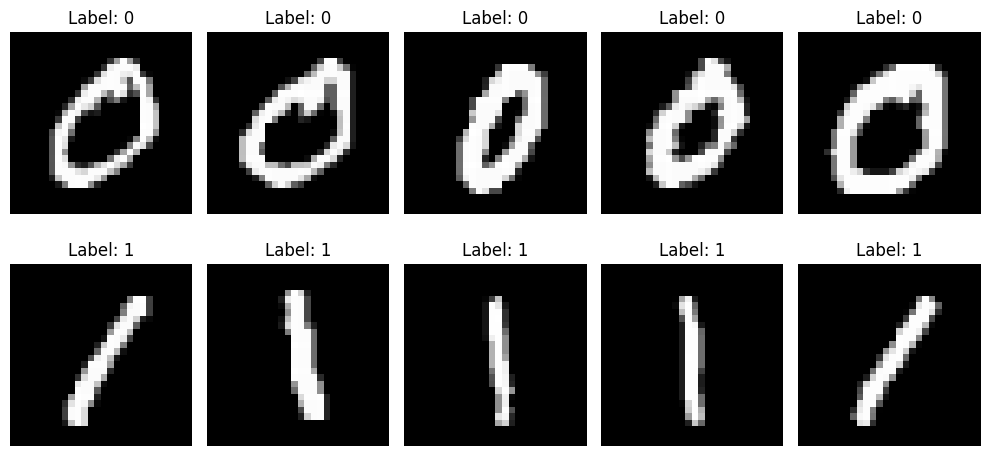

In [49]:
images_0= X[y == 0]  # Images corresponding to label 0
images_1= X[y == 1]  # Images corresponding to label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if(len(images_0) >= 5 and len(images_1) >= 5):
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(f"Label: 0")
        axes[0, i].axis('off')

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(f"Label: 1")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


In [50]:
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100



What does the weights array represent in this context?
The weights array represents the importance or contribution of each pixel in the input images towards the final classification decision made by the perceptron. Each weight corresponds to a specific pixel, and during training, these weights are adjusted based on the error between the predicted output and the actual label. The learning process involves updating these weights to minimize the classification error, allowing the perceptron to learn how to distinguish between images of digits 0 and 1 effectively.



Why are we initializing the weights to zero? What effect could this
have on the training process?

Initializing the weights to zero is a common practice in the perceptron algorithm, as it provides a neutral starting point for the learning process. However, this can lead to a situation where all neurons in the network learn the same features during training, especially if the input data is symmetric. This is because if all weights are initialized to the same value (zero in this case), they will be updated in the same way during training, leading to a lack of diversity in the learned features. This can slow down the convergence of the algorithm and may result in suboptimal performance. To mitigate this issue, it is often recommended to initialize weights randomly or using small random values instead of zeros.

In [51]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)  # Step function
    return y_pred_all

In [52]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
        Parameters:
        - X: Features (input data) as a numpy array of shape (n_samples, n_features)
        - y: Labels (true output) as a numpy array of shape (n_samples,)
        - weights: Initial weights as a numpy array of shape (n_features,)
        - bias: Initial bias value (scalar)
        - learning_rate: Learning rate for weight updates (default is 0.1)
        - epochs: Number of iterations to train the model (default is 100)
        Returns:
        - weights: Updated weights after training
        - bias: Updated bias after training
        - accuracy: Total correct prediction.
    """

    for epoch in range(epochs):
        for i in range(X.shape[0]):
            y_pred = decision_function(X[i], weights, bias)
            error = y[i] - y_pred
            weights += learning_rate * error * X[i]  # Update weights
            bias += learning_rate * error  # Update bias

    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred_all == y) / len(y)  # Calculate accuracy
    return weights, bias, accuracy


In [53]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"Trained Weights: {weights}")
print(f"Trained Bias: {bias}")
print(f"Training Accuracy: {accuracy * 100:.2f}%")

Trained Weights: [   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     4.5   73.5
   17.7    0.    30.6   71.7   17.1    0.     0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
    0.     0.     5.4    4.8    0.     0.    37.4   66.8   57.2   49.4
  101.8  113.8   43.3   14.7   22.2   10.1    0.     0.     0.     0.
    0.     0.     0.     0.     0.     0.     0.     0.    -5.    -8.
   42.6   66.7   16.1    9.9   57.6   99.5  123.2  100.8   33.9   67.9
  -29.9  114.4  110.6   65.6   21.4    8.     0.     0.     0.     0.


What happens when the prediction is wrong? How are the weights and
bias updated?

When the prediction is wrong, the error is calculated as the difference between the true label (y[i]) and the predicted label (y_pred). The weights and bias are then updated using the following rules:
- Weights are updated by adding the product of the learning rate, error, and the input features (X[i]) to the current weights.
- Bias is updated by adding the product of the learning rate and error to the current bias.


Question - 7:Why is the final accuracy important, and what do you expect it to be?

The final accuracy is important because it indicates how well the perceptron has learned to classify the data. It measures the proportion of correctly classified samples out of the total samples. A high accuracy means that the model is performing well on the training data, while a low accuracy indicates that the model may not have learned the underlying patterns effectively.

#Visualizing the Misclassified Image:

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

IndentationError: expected an indented block after 'if' statement on line 8 (536789938.py, line 9)